In [1]:
import torch
import torch.nn as nn
from models.model.encoder import TransformerEmbedding
from models.blocks.encoder_layer import EncoderLayer
from conf import *


In [2]:
#just high level visualization 
'''High Level flow:
        Text 
         |
         Token Id
         |
        Token Embeddings 
         |
        Positional Embeddings
         |
        Padding
         |
        Masking
         |
        data to encoder block
         |
        train
'''

'High Level flow:\n        Text \n         |\n         Token Id\n         |\n        Token Embeddings \n         |\n        Positional Embeddings\n         |\n        Padding\n         |\n        Masking\n         |\n        data to encoder block\n         |\n        train\n'

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "train.csv"

# Load the latest version
train_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abhi8923shriv/sentiment-analysis-dataset",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}
)

file_path = "test.csv"

# Load the latest version
test_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abhi8923shriv/sentiment-analysis-dataset",
  file_path,
  pandas_kwargs={"encoding": "latin-1"}
)

/home/faizan/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_62007/1980899396.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train_df = kagglehub.load_dataset(
/tmp/ipykernel_62007/1980899396.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  test_df = kagglehub.load_dataset(


# Data Preprocess

### Seprate and take the important  data content

In [4]:
train_df = train_df.dropna()
test_df = test_df.dropna()
train_df = train_df[['text','sentiment']]
test_df = test_df[['text','sentiment']]

### Maked simple func to easily apply on the text

In [5]:
def tokenize(text):
    return text.lower().split()

### Data Info

In [6]:
# Inspect the data
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("\nTrain df columns:", train_df.columns.tolist())
print("\nFirst few rows of train_df:")
print(train_df.head())
print("\nValue counts for sentiment:")
print(train_df['sentiment'].value_counts())

Train df shape: (27480, 2)
Test df shape: (3534, 2)

Train df columns: ['text', 'sentiment']

First few rows of train_df:
                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative

Value counts for sentiment:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


### Class Imbalance Weights



In [7]:
neutral_count= len(train_df[train_df['sentiment'] == 'neutral']) 
positive_count = len(train_df[train_df['sentiment'] == 'positive']) 
negative_count = len(train_df[train_df['sentiment'] == 'negative']) 

counts = torch.tensor([neutral_count,positive_count,negative_count])
total_count = counts.sum()

# 1. invert the fractions 
raw_weights =  total_count / counts


# 3. Normaliza (sum to 1)
norm_weights = raw_weights / raw_weights.sum() 
norm_weights = norm_weights.to(device=device)
display(norm_weights)

tensor([0.2685, 0.3478, 0.3836], device='cuda:0')

### 
```text
    - checking the len for deciding the max_len or seq_len parameter

In [8]:
train_df.loc[train_df['text'].str.split().str.len() > 35]

,text,sentiment


# Tokenization and Padding and Masking 

```text
    * filled empty string for empty values and extracted the text in list 
    * Used Tokenizer for creating the token and using max_len(seq_len) and oov_token to prevent the remove of unknown word
    * then calling the .text_to_sequences to get token_ids
    * Applying and fixing padding length ensuring the seqence length shouldl be same after padding 
    * Then showing the information about the data 


In [9]:
import numpy as np
from keras_preprocessing.text import Tokenizer

# Tokenize train and test text
train_texts = train_df['text'].fillna('').values
test_texts = test_df['text'].fillna('').values
train_labels = train_df['sentiment'].values
test_labels = test_df['sentiment'].values

# Create tokenizer from training data
tokenizer = Tokenizer(num_words=max_len, oov_token='<unk>')
tokenizer.fit_on_texts(train_texts)

# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Manual padding to fixed length
def pad_sequences_manual(sequences, maxlen, padding='post', pad_value=0):
    # fill the sentence for sequences end to maxlen with padding values for maintaing the shape 
    padded = np.full((len(sequences), maxlen), pad_value, dtype=np.int32)
    for i, seq in enumerate(sequences):
        if len(seq) > maxlen:
            padded[i] = seq[:maxlen]
        else:
            if padding == 'post':
                padded[i, :len(seq)] = seq
            else:  # 'pre'
                padded[i, -len(seq):] = seq
    return padded

train_padded = pad_sequences_manual(train_sequences, maxlen=max_len, padding='post')
test_padded = pad_sequences_manual(test_sequences, maxlen=max_len, padding='post')

print("Train sequences shape:", train_padded.shape)
print("Test sequences shape:", test_padded.shape)
print("Vocab size:", len(tokenizer.word_index))
print("\nExample train sequence (first 10 tokens):", train_padded[0][:10])
print("Example train label:", train_labels[0])

Train sequences shape: (27480, 40)
Test sequences shape: (3534, 40)
Vocab size: 26599

Example train sequence (first 10 tokens): [ 2  1 20  1  1  2  1  1  0  0]
Example train label: neutral


```bash
    * creating vocab :
        - token to id for encoding the token
        - if to token for decoding the token 

In [10]:
special_tokens = ['<PAD>', '<UNK>']

vocab = {token: idx for idx, token in enumerate(special_tokens)}

for word, index in tokenizer.word_index.items():
    if index >= max_len:
        continue
    if word not in vocab:
        vocab[word] = len(vocab)

id_to_word = {idx: word for word, idx in vocab.items()}

print('Vocabulary size:', len(vocab))
print('Sample vocab entries:', list(vocab.items())[:20])


Vocabulary size: 41
Sample vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('<unk>', 2), ('i', 3), ('to', 4), ('the', 5), ('a', 6), ('my', 7), ('it', 8), ('you', 9), ('and', 10), ('is', 11), ('in', 12), ('for', 13), ('s', 14), ('of', 15), ('t', 16), ('that', 17), ('on', 18), ('me', 19)]


# Preparing the dataset for the training 

### 
```text
    * filling null or empty values with the neutral label in train and test 
    * then created label ids and ids to label 
    * changing labels into numpy arrays then rypecast into torch.LongTensors
    * created the masking of the trainPadding and testPadding
    * Coverted into the TensorDataset to prevent the training error and ease to train 
    * Then used DataLoader for ease to train in batch 
    * In the End Shows the info and the detail of the data 




In [11]:
# Handle missing labels
import pandas as pd

train_labels = pd.Series(train_labels).fillna('neutral').values
test_labels = pd.Series(test_labels).fillna('neutral').values

# Convert string labels to numeric
label_to_id = {'negative': 0, 'neutral': 1, 'positive': 2}
id_to_label = {v: k for k, v in label_to_id.items()}

train_labels_numeric = np.array([label_to_id[label] for label in train_labels])
test_labels_numeric = np.array([label_to_id[label] for label in test_labels])

# Convert to PyTorch tensors
train_tensor = torch.LongTensor(train_padded)
train_labels_tensor = torch.LongTensor(train_labels_numeric)
test_tensor = torch.LongTensor(test_padded)
test_labels_tensor = torch.LongTensor(test_labels_numeric)

# Create PyTorch datasets and dataloaders
from torch.utils.data import TensorDataset, DataLoader

#Creating the train and test  Mask of the padded tokens 
train_mask = train_padded != 0
train_mask = torch.tensor(train_mask,dtype=torch.long)
test_mask = test_padded != 0 
test_mask = torch.tensor(test_mask,dtype=torch.long)

#Converting into tensor dataset by concatanating 
train_dataset = TensorDataset(train_tensor,train_mask,train_labels_tensor)
test_dataset = TensorDataset(test_tensor,test_mask,test_labels_tensor)

#Creating train_loader and test_loader for ease in training 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train loader batches:", len(train_loader))
print("Test loader batches:", len(test_loader))
print("Batch size:", batch_size)
print("\nLabel mapping:", label_to_id)

# Get first batch to verify
for batch_x,mask_x,batch_y in train_loader:
    print("\nFirst batch shape - X:", batch_x.shape,"X_mask:",mask_x.shape ,"Y:", batch_y.shape)
    print("First sample in batch (first 20 tokens):", batch_x[0][:20])
    print("First sample in batch (first 20 tokens):", mask_x[0][:20])
    print("First label in batch:", batch_y[0].item(), "->", id_to_label[batch_y[0].item()])
    break

Train loader batches: 859
Test loader batches: 111
Batch size: 32

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

First batch shape - X: torch.Size([32, 40]) X_mask: torch.Size([32, 40]) Y: torch.Size([32])
First sample in batch (first 20 tokens): tensor([ 1,  5,  1, 24,  1, 14,  6,  1,  1,  1,  1, 19,  2,  1, 26,  1,  3,  1,
         0,  0])
First sample in batch (first 20 tokens): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0])
First label in batch: 0 -> negative


### 
```text
    * view of the train_loader dataset

In [12]:
for batch_x,mask_x,batch_y in train_loader:
    print("\nFirst batch shape - X:", batch_x.shape,"X_mask:",mask_x.shape ,"Y:", batch_y.shape)
    print("First sample in batch (first 20 tokens):", batch_x[1])
    print("First sample in batch (first 20 tokens):", mask_x[1])
    print("First label in batch:", batch_y[0].item(), "->", id_to_label[batch_y[0].item()])
    break


First batch shape - X: torch.Size([32, 40]) X_mask: torch.Size([32, 40]) Y: torch.Size([32])
First sample in batch (first 20 tokens): tensor([9, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
First sample in batch (first 20 tokens): tensor([1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
First label in batch: 2 -> positive


# Single Encoder Block 

###
```text
    - Created a Single encoder Block with the Refrence from the Hugging_Face_PipeLine_4.ipynb

In [13]:

embeddings = TransformerEmbedding(vocab_size=len(train_dataset),d_model=d_model,max_len=max_len,drop_prob=drop_prob,device=device)

class SingleBlockTransformerClassifier(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, max_len,device='cpu'):
        super().__init__()
        self.device = device
        
        self.encoder = EncoderLayer(d_model=d_model, ffn_hidden=d_ff,n_head=num_heads,drop_prob=drop_prob,max_len=max_len,device=device)
        
        
    def forward(self, x, attention_mask=None):
        
        
        encoder_output = self.encoder(x, attention_mask)
        
        return encoder_output

### Defined the VocabSize

In [14]:
vocab_size  = len(tokenizer.word_index)


###
```text 
    * Didn't used just used from refrence to try how the masking is work throw .masked_fill but normal logic is worked "train_mask = train_padded != 0" and just typecast this into and torch.Long

In [15]:
def create_mask(input_id):
    if input_id is not None:
        # attention_mask shape: (B, T)
        # converted to: (B, 1, 1, T)
        mask = input_id[:, None, None, :]
        scores = scores.masked_fill(mask == 0, float("-inf"))
        

In [16]:
train_padded[0]

array([ 2,  1, 20,  1,  1,  2,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0], dtype=int32)

In [17]:
train_padded[0].shape

(40,)

# Training 

## Dataset 

In [18]:
train_labels_tensor[0]

tensor(1)

### Taken by the refrence Hugging_Face_PipeLine_4.ipynb but didnt worked in the way that i need, so i used the DataLoader 

In [19]:
# from torch.utils.data import Dataset, DataLoader
# torch.manual_seed(42)

# class SentimentDataset(Dataset):
#     def __init__(self, input_ids, attention_masks, labels):
#         self.input_ids = torch.tensor(input_ids, dtype=torch.long)
#         self.attention_masks = torch.tensor(attention_masks, dtype=torch.long)
#         self.labels = torch.tensor(labels, dtype=torch.long)
        
#     def __len__(self):
#         return len(self.labels)
    
#     def __getitem__(self, idx):
#         return {
#             "input_ids": self.input_ids[idx],
#             "attention_mask": self.attention_masks[idx],
#             "label": self.labels[idx]
#         }
# dataset = SentimentDataset(train_padded,mask,labels=train_labels_tensor)
# sample = dataset[0]
# print(sample)

In [20]:
# dataloader = DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True)

## Model Initialization

## Classifier Head 

In [21]:
class ClassifierHead(nn.Module):
    def __init__(self, d_model, num_classes, device='cpu'):
        super().__init__()
        self.device = device
        self.classifier = nn.Linear(d_model, num_classes).to(device)
    def forward(self, encoder_output, attention_mask=None):
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).to(encoder_output.dtype)
            pooled = (encoder_output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        else:
            pooled = encoder_output.mean(dim=1)
        return self.classifier(pooled)

## Encoder Stacked Blocks

In [ ]:
class EncoderBlocks(nn.Module):
    def __init__(self,vocab_size,d_model,d_ff,num_heads,max_len,num_classes,device='cpu'):
        super(EncoderBlocks,self).__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0,device=device)
        self.position_embedding = nn.Embedding(max_len, d_model,device=device)
        self.device = device 
        self.layers = nn.ModuleList([
            SingleBlockTransformerClassifier(
                d_model=d_model,
                d_ff=d_ff,
                num_heads=num_heads,
                max_len=max_len,
                device=device)  for _ in range(n_layers)]
        )
    def forward(self,x,att_mask):
        B, T = x.shape
        
        positions = torch.arange(T, device=self.device).unsqueeze(0).expand(B, T)
        
        token_emb = self.token_embedding(x)
        pos_emb = self.position_embedding(positions)
        
        x = token_emb + pos_emb
        
        for layer in self.layers:
            x = layer(x, att_mask)
        
        return x

## 
```text
    - initialized the EncoderBlocks , classifier_head
    - initialized the lr_scheduler
    - 

### Early Stopping 

In [23]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [30]:
# Stacked Encoder Block
encoder =  EncoderBlocks(
    vocab_size=vocab_size,
    d_model=d_model,
    d_ff=ffn_hiiden,
    num_heads=n_head,
    max_len=max_len,
    num_classes=num_classes,
    device=device
    )
early_stopping = EarlyStopping(patience=5, delta=0.01)
classifier_head = ClassifierHead(d_model=d_model,num_classes=num_classes,device=device)
model = encoder.to(device)

import torch.nn as nn
criterion = nn.CrossEntropyLoss(weight=norm_weights)

# Optimizer: discriminative LRs and AdamW with weight decay
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR,LambdaLR

#collecting encoder params 


# parameter groups: lower LR for embeddings+encoder, higher LR for classifier head
encoder_params = list(encoder.layers.parameters())
classifier_params = list(classifier_head.classifier.parameters())
base_lr = lr  # from conf.py

optimizer = AdamW([
    {'params': encoder_params, 'lr': base_lr * 0.1},
    {'params': classifier_params, 'lr': base_lr},
], weight_decay=weight_decay, eps=adam_eps)

# Linear warmup scheduler (warmup steps = `warmup`), then keep constant; call scheduler.step() each optimizer.step()
def lr_lambda(current_step):
    if warmup <= 0:
        return 1.0
    return min(1.0, float(current_step) / float(max(1, warmup)))

# scheduler = StepLR(optimizer, step_size=patience,gamma=0.5)
scheduler = LambdaLR(optimizer,lr_lambda)

print('Optimizer and scheduler created. Base LR:', base_lr)


Optimizer and scheduler created. Base LR: 0.0001


## Model learning Phase 
```text
    - it will store the each iteration avg_loss and avg_acc in a list for model visualize the model performance 
    - created the validation data also for checking the model generalization power on each epoch 
    - computing val_avgLoss and val_acc for saving the best model while learning 
    - printing the info on each 10 epoch 

In [31]:
import matplotlib.pyplot as plt
from pathlib import Path
import torch

model.train()
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')
best_model_path = Path('saved_model/best_model.pth')

for i in range(epoch):
    total_loss = 0
    total_correct = 0

    for x_batch, x_mask, y_batch in train_loader:
        input_ids = x_batch.to(device)
        att_mask = x_mask.to(device)
        labels_batch = y_batch.to(device)

        encoder_out = model(input_ids, att_mask)
        logits = classifier_head(encoder_out, att_mask)

        loss = criterion(logits, labels_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_correct += (logits.argmax(dim=1) == labels_batch).sum().item()

    avg_loss = total_loss / len(train_loader)
    avg_accuracy = total_correct / len(train_loader.dataset)

    train_losses.append(avg_loss)
    train_accuracies.append(avg_accuracy)

    # Validation
    model.eval()
    val_total_loss = 0
    val_total_correct = 0
    val_total_examples = 0
    with torch.no_grad():
        for vx, vmask, vy in test_loader:
            vx = vx.to(device)
            vmask = vmask.to(device)
            vy = vy.to(device)
            enc_out = model(vx, vmask)
            v_logits = classifier_head(enc_out,vmask)
            v_loss = criterion(v_logits, vy)
            val_total_loss += v_loss.item()
            val_total_correct += (v_logits.argmax(dim=1) == vy).sum().item()
            val_total_examples += vy.size(0)

    avg_val_loss = val_total_loss / len(test_loader) if len(test_loader) > 0 else 0
    avg_val_acc = val_total_correct / val_total_examples if val_total_examples > 0 else 0

    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    # Save best model by validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

    model.train()

    if (i + 1) % 10 == 0:
        print(f"Epoch {i + 1}  | Train Loss: {avg_loss:.4f} | Train Acc: {avg_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")
        print(f'New best model saved (epoch {i+1}) with val_loss {best_val_loss:.4f}')


print('Best model saved to', best_model_path)


Epoch 10  | Train Loss: 1.0134 | Train Acc: 0.4541 | Val Loss: 1.0121 | Val Acc: 0.4516
New best model saved (epoch 10) with val_loss 1.0121
Epoch 20  | Train Loss: 0.9995 | Train Acc: 0.4664 | Val Loss: 1.0039 | Val Acc: 0.4703
New best model saved (epoch 20) with val_loss 1.0019
Epoch 30  | Train Loss: 0.9925 | Train Acc: 0.4729 | Val Loss: 0.9968 | Val Acc: 0.4717
New best model saved (epoch 30) with val_loss 0.9968
Epoch 40  | Train Loss: 0.9869 | Train Acc: 0.4791 | Val Loss: 0.9959 | Val Acc: 0.4796
New best model saved (epoch 40) with val_loss 0.9952
Epoch 50  | Train Loss: 0.9834 | Train Acc: 0.4834 | Val Loss: 0.9936 | Val Acc: 0.4839
New best model saved (epoch 50) with val_loss 0.9924
Epoch 60  | Train Loss: 0.9797 | Train Acc: 0.4884 | Val Loss: 0.9908 | Val Acc: 0.4864
New best model saved (epoch 60) with val_loss 0.9908
Epoch 70  | Train Loss: 0.9766 | Train Acc: 0.4898 | Val Loss: 0.9899 | Val Acc: 0.4890
New best model saved (epoch 70) with val_loss 0.9898
Epoch 80  | T

## Model Evalutation Phase
```text
    - loading the best model that is saved while training 
    - saving all the preds into an numpy array 
    - using the sklearn then printing classificaton report and confusion matring for seeing the model strength and weakness 
    - plotting the confusion matrix

Test Accuracy: 0.2903
Classification report:
              precision    recall  f1-score   support

    negative       0.29      0.99      0.45      1001
     neutral       0.13      0.01      0.02      1430
    positive       0.62      0.02      0.04      1103

    accuracy                           0.29      3534
   macro avg       0.35      0.34      0.17      3534
weighted avg       0.33      0.29      0.15      3534



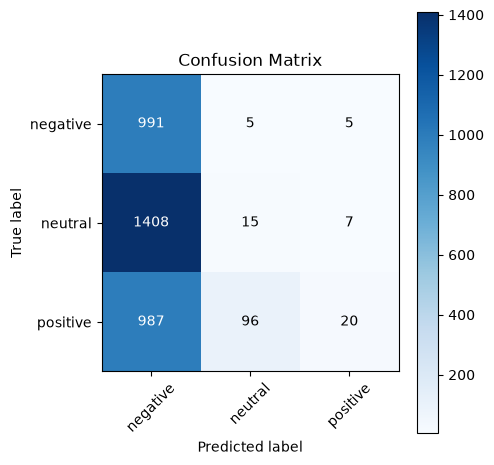

Saved evaluation results to eval_results.json


In [ ]:
# Evaluation on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

best_model_path = Path('saved_model/best_model.pth')
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, mask, y in test_loader:
            x = x.to(device)
            mask = mask.to(device)
            y = y.to(device)
            encoder_out = model(x, mask)
            logits = classifier_head(encoder_out,mask)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(y.cpu().numpy().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    test_acc = (all_preds == all_labels).mean() if len(all_labels)>0 else 0.0
    print(f'Test Accuracy: {test_acc:.4f}')

    # Try sklearn classification report and confusion matrix if available
    try:
        from sklearn.metrics import classification_report, confusion_matrix
        print('Classification report:')
        print(classification_report(all_labels, all_preds, target_names=['negative','neutral','positive']))
        cm = confusion_matrix(all_labels, all_preds)
    except Exception as e:
        print('sklearn not available or error:', e)
        cm = None

    # Plot confusion matrix if available
    if cm is not None:
        plt.figure(figsize=(5,5))
        plt.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.colorbar()
        ticks = [0,1,2]
        labels = ['negative','neutral','positive']
        plt.xticks(ticks, labels, rotation=45)
        plt.yticks(ticks, labels)
        thresh = cm.max() / 2. if cm.max()>0 else 0.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center', color='white' if cm[i,j]>thresh else 'black')
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

    # Save predictions and metrics
    import json
    out = {'accuracy': float(test_acc), 'preds': all_preds.tolist(), 'labels': all_labels.tolist()}
    if cm is not None:
        out['confusion_matrix'] = cm.tolist()
    Path('eval_results.json').write_text(json.dumps(out))
    print('Saved evaluation results to eval_results.json')
else:
    print('best_model.pth not found - run training and ensure the best model is saved before evaluation')


## Model Performance 
```text
    - visualizing the model performance to see the hidden patter

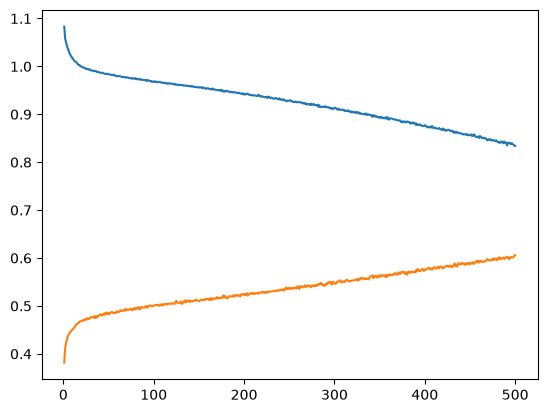

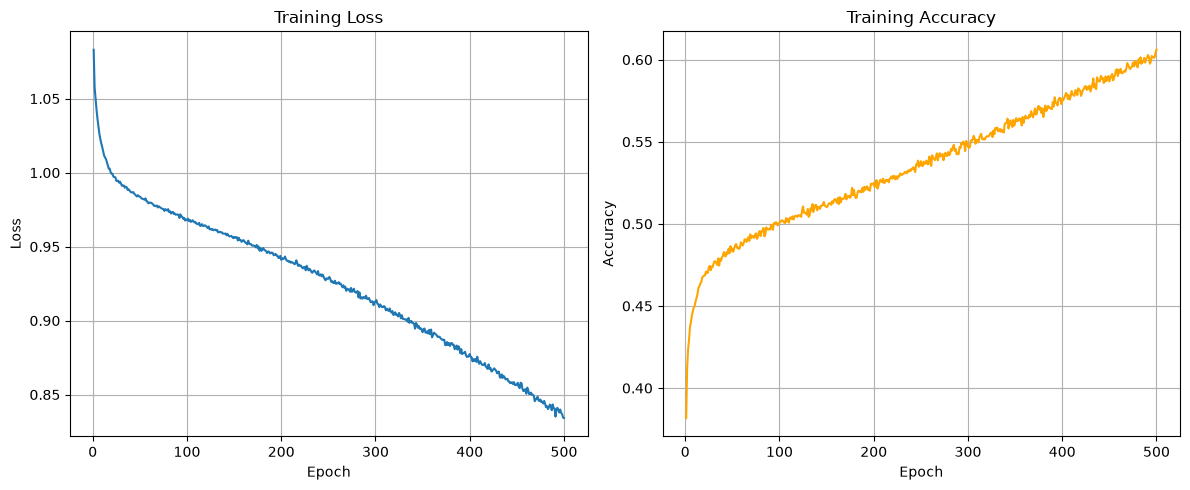

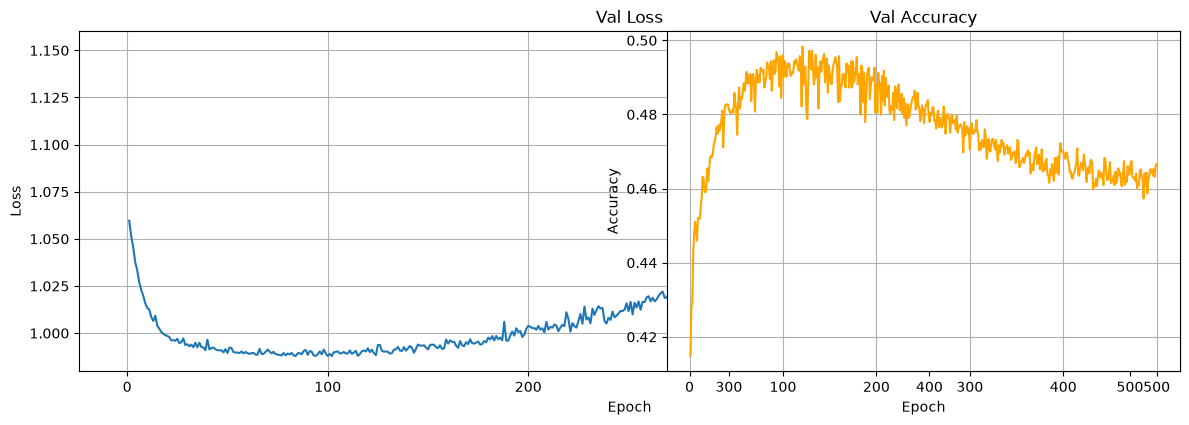

In [ ]:
epochs = list(range(1, epoch + 1))
plt.plot(epochs,train_losses)
plt.plot(epochs,train_accuracies)
plt.show()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, color='orange')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(epochs, val_losses)
plt.title('Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, color='orange')
plt.title('Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# import numpy as np

# def pad_sequences(seqs, pad_value=0, max_len=None):
#     """
#     Returns: np.ndarray of shape (N, L) where:
#       N = len(seqs)
#       L = max_len if provided else max(len(seq) for seq in seqs) or 0
#     """
#     if seqs is None:
#         return np.array(0)
#     if max_len is None:
#         max_len = max(len(seq) for seq in seqs)
#     padded_seqs = np.full((len(seqs),max_len),pad_value ,dtype=np.int32)
#     for i,s in enumerate(seqs):
#         if len(s) > max_len:
#             padded_seqs[i] = s[:max_len] 
#         else:
#             padded_seqs[i, :len(s)] = s 
            
#     return padded_seqs
# s  =[[1,2,3,4],[5,6]]
# pad = 0
# max_len = 3 
# pad_sequences(s,pad_value=pad,max_len=max_len)


array([[1, 2, 3],
       [5, 6, 0]], dtype=int32)